# Module 04, Part 3: The LSTM and its gates

This notebook is the runnable companion to Part 3 of the Module 04 learning
content. It checks, with code:

1. The four-gate LSTM update written by hand matches `nn.LSTM` exactly, so you
   know what each gate does.
2. At default initialization the forget gate starts near 0.5, and what that
   does to a memory carried over 30 steps.
3. Measured gradients: gates alone do **not** fix vanishing. An open forget gate
   does.
4. The same story on a task: delayed recall over 30 steps, where only the
   open-gate LSTM learns.

Everything runs on CPU in a few minutes.

In [17]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

INK, BODY, MUTED = "#14161B", "#4E5563", "#7C838C"
NAVY, GREEN, AMBER, KEY, RULE = "#1C3D6E", "#0E6B57", "#8A6A18", "#7A2E8A", "#D9DCE2"

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": RULE, "axes.labelcolor": BODY, "xtick.color": BODY, "ytick.color": BODY,
    "axes.grid": True, "grid.color": RULE, "font.size": 10,
})

torch.manual_seed(0)
print("PyTorch version:", torch.__version__)
count = lambda module: sum(p.numel() for p in module.parameters())

PyTorch version: 2.10.0+cpu


## 1. The four gates, written by hand

The LSTM keeps a cell state $c_t$ that it updates by **addition**:

$$c_t = f_t \odot c_{t-1} + i_t \odot g_t, \qquad h_t = o_t \odot \tanh(c_t)$$

Here $f_t$ is the forget gate, $i_t$ the input gate, $g_t$ the candidate and
$o_t$ the output gate. PyTorch stores the four weight blocks stacked in the
order **input, forget, candidate (cell), output**. We unpack them ourselves and
compare with `nn.LSTM`.

In [18]:
F, H, T, B = 8, 32, 20, 4
lstm = nn.LSTM(F, H, batch_first=True)
print("Parameters, LSTM:", count(lstm), "  plain RNN:", count(nn.RNN(F, H)), "  (four weight blocks instead of one)")

x = torch.randn(B, T, F)
W_ih, W_hh = lstm.weight_ih_l0, lstm.weight_hh_l0          # each stacks 4 blocks: (4H, F) and (4H, H)
b = lstm.bias_ih_l0 + lstm.bias_hh_l0

h = torch.zeros(B, H)
c = torch.zeros(B, H)
outputs = []
for t in range(T):
    gates = x[:, t] @ W_ih.T + h @ W_hh.T + b
    i, f, g, o = gates.chunk(4, dim=1)                      # input, forget, candidate, output
    i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
    g = torch.tanh(g)
    c = f * c + i * g                                       # additive update of the cell state
    h = o * torch.tanh(c)
    outputs.append(h)
manual = torch.stack(outputs, dim=1)

out, (h_n, c_n) = lstm(x)
print("Hand-written LSTM matches nn.LSTM:", torch.allclose(manual, out, atol=1e-6))
print("Final cell state matches too:     ", torch.allclose(c, c_n[0], atol=1e-6))

Parameters, LSTM: 5376   plain RNN: 1344   (four weight blocks instead of one)
Hand-written LSTM matches nn.LSTM: True
Final cell state matches too:      True


## 2. Where the forget gate starts

When $f_t$ is close to 1, the old cell state passes through almost unchanged
and the gradient flows back through it with it. At default initialization the
gate starts near 0.5. We measure the average forget-gate value on random input,
for the default bias and for a forget bias of 3.

In [19]:
def mean_forget_gate(module):
    W_ih, W_hh = module.weight_ih_l0, module.weight_hh_l0
    b = module.bias_ih_l0 + module.bias_hh_l0
    h, c = torch.zeros(B, H), torch.zeros(B, H)
    values = []
    for t in range(T):
        gates = x[:, t] @ W_ih.T + h @ W_hh.T + b
        i, f, g, o = gates.chunk(4, dim=1)
        i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g)
        values.append(f.mean().item())
        c = f * c + i * g
        h = o * torch.tanh(c)
    return sum(values) / len(values)

def with_forget_bias(value):
    m = nn.LSTM(F, H, batch_first=True)
    with torch.no_grad():
        m.bias_ih_l0[H:2 * H].fill_(value / 2)      # forget gate is slice [H : 2H]
        m.bias_hh_l0[H:2 * H].fill_(value / 2)      # effective bias = sum of the two = value
    return m

torch.manual_seed(0)
for name, module in (("default", nn.LSTM(F, H, batch_first=True)), ("forget bias 3", with_forget_bias(3.0))):
    mean_f = mean_forget_gate(module)
    print(f"{name:14s} mean forget gate ~ {mean_f:.2f}   fraction of a memory left after 30 steps ~ {mean_f ** 30:.1e}")

default        mean forget gate ~ 0.51   fraction of a memory left after 30 steps ~ 1.4e-09
forget bias 3  mean forget gate ~ 0.95   fraction of a memory left after 30 steps ~ 2.2e-01


A gate near 0.5 keeps $0.5^{30} \approx 10^{-9}$ of the old memory after 30
steps; a gate near 0.95 keeps about 21%. That one number is the whole story of
the next section.

## 3. Do gates fix vanishing gradients? Measure it

Same experiment as Part 2: hidden size 32, 60 steps, loss from the final step
only, gradient norm at every input step, median over five seeds.

In [20]:
def grad_by_distance(make_model, seq_len=60, batch=16, n_inputs=8, seeds=range(5)):
    """Gradient norm reaching each input step when the loss reads only the last
    step. Index k of the result is the gradient k steps back from the loss.
    Median over seeds."""
    rows = []
    for seed in seeds:
        torch.manual_seed(seed)
        model = make_model()
        x = torch.randn(batch, seq_len, n_inputs, requires_grad=True)
        out, _ = model(x)
        out[:, -1, :].pow(2).sum().backward()
        rows.append(x.grad.norm(dim=(0, 2)).flip(0))
    return torch.stack(rows).median(dim=0).values.numpy()


def set_gate_bias(module, value, hidden=32):
    """Open the LSTM forget gate or GRU update gate (slice [H:2H] of the bias block)."""
    with torch.no_grad():
        module.bias_ih_l0[hidden:2 * hidden].fill_(value / 2)
        module.bias_hh_l0[hidden:2 * hidden].fill_(value / 2)
    return module

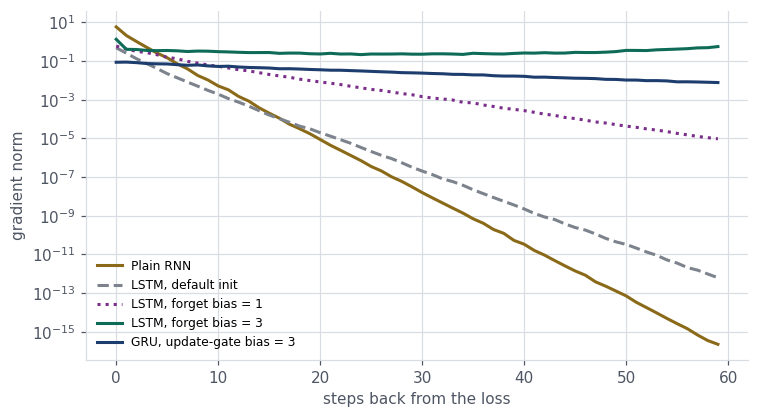

                                0 back    9 back   29 back   59 back
Plain RNN                      5.8e+00   1.0e-02   3.1e-08   2.3e-16
LSTM, default init             4.8e-01   3.0e-03   3.3e-07   6.3e-13
LSTM, forget bias = 1          5.9e-01   6.2e-02   1.8e-03   9.5e-06
LSTM, forget bias = 3          1.3e+00   3.2e-01   2.3e-01   5.6e-01
GRU, update-gate bias = 3      8.6e-02   5.6e-02   2.5e-02   7.7e-03


In [21]:
def make(kind, bias=None):
    def build():
        cell = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind](8, 32, batch_first=True)
        return set_gate_bias(cell, bias) if bias is not None else cell
    return build

series = {
    "Plain RNN": (make("rnn"), AMBER, "-"),
    "LSTM, default init": (make("lstm"), MUTED, "--"),
    "LSTM, forget bias = 1": (make("lstm", 1.0), KEY, ":"),
    "LSTM, forget bias = 3": (make("lstm", 3.0), GREEN, "-"),
    "GRU, update-gate bias = 3": (make("gru", 3.0), NAVY, "-"),
}
results = {name: grad_by_distance(build) for name, (build, _, _) in series.items()}

fig, ax = plt.subplots(figsize=(7, 3.9))
for name, (_, color, style) in series.items():
    ax.plot(results[name], color=color, ls=style, lw=2, label=name)
ax.set_yscale("log")
ax.set_xlabel("steps back from the loss")
ax.set_ylabel("gradient norm")
ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

print(f"{'':28s}{'0 back':>10s}{'9 back':>10s}{'29 back':>10s}{'59 back':>10s}")
for name, g in results.items():
    print(f"{name:28s}" + "".join(f"{g[k]:>10.1e}" for k in (0, 9, 29, 59)))

Read the table carefully. The LSTM at **default initialization** still loses
gradient with distance, and a forget bias of 1 only partly helps. A forget bias
of 3 keeps the gradient roughly flat over all 60 steps. Having gates is not
enough on its own: whether the network starts out using its additive path is an
initialization question.

## 4. The same story on a task: delayed recall over 30 steps

Now the practical version. Step 0 carries a class label, the next 29 steps are
noise, and the label must be reported at the last step. Chance is 25%. We train
each model for 600 updates with the same data, optimizer and gradient clipping,
and change only the cell and its starting gate bias.

In [22]:
def make_recall_batch(batch_size, seq_len, generator, n_classes=4, noise_dim=2):
    """Delayed recall. Step 0 carries a class label as a one-hot vector in the
    first n_classes features. Every later step carries only noise. The label
    is read out at the LAST step, so the network must carry it across
    seq_len - 1 steps of distraction."""
    labels = torch.randint(0, n_classes, (batch_size,), generator=generator)
    x = torch.randn(batch_size, seq_len, n_classes + noise_dim, generator=generator) * 0.5
    x[:, :, :n_classes] = 0.0
    x[torch.arange(batch_size), 0, labels] = 1.0
    return x, labels


class RecallNet(nn.Module):
    """A recurrent layer followed by a linear classifier that reads the LAST step."""

    def __init__(self, kind, hidden=32, gate_bias=None, n_inputs=6, n_classes=4):
        super().__init__()
        cell = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[kind]
        self.rnn = cell(n_inputs, hidden, batch_first=True)
        self.head = nn.Linear(hidden, n_classes)
        # gate_bias opens the LSTM forget gate or the GRU update gate at the start.
        # PyTorch stores the gates in one block: LSTM (input, forget, cell, output),
        # GRU (reset, update, new). Slice [H:2H] is the forget gate or the update gate.
        # There are two bias vectors; their sum is the effective bias, so split it.
        if gate_bias is not None and kind in ("lstm", "gru"):
            with torch.no_grad():
                self.rnn.bias_ih_l0[hidden:2 * hidden].fill_(gate_bias / 2)
                self.rnn.bias_hh_l0[hidden:2 * hidden].fill_(gate_bias / 2)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])


def train_recall(kind, seq_len, seed=0, gate_bias=None, steps=600, batch_size=64,
                 lr=3e-3, clip=1.0, eval_every=50):
    """Train on the delayed-recall task. Returns (final_accuracy, history)."""
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed + 100)
    model = RecallNet(kind, gate_bias=gate_bias)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    eval_gen = torch.Generator().manual_seed(999)
    x_val, y_val = make_recall_batch(1000, seq_len, eval_gen)
    history = []
    for step in range(1, steps + 1):
        x, y = make_recall_batch(batch_size, seq_len, gen)
        loss = nn.functional.cross_entropy(model(x), y)
        opt.zero_grad()
        loss.backward()
        if clip:
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        if step % eval_every == 0:
            with torch.no_grad():
                history.append((step, (model(x_val).argmax(1) == y_val).float().mean().item()))
    return history[-1][1], history

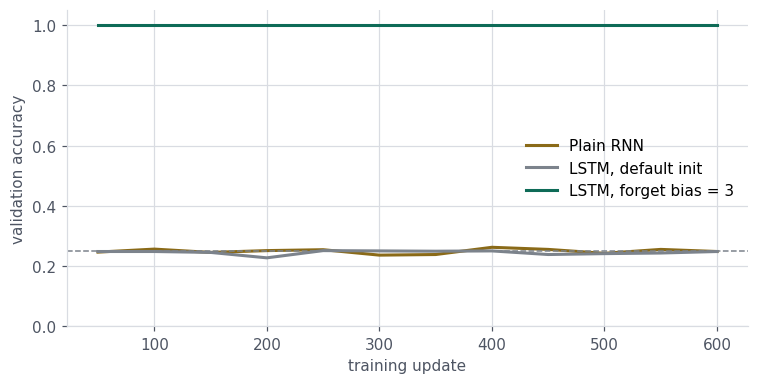

Plain RNN                accuracy after 600 updates: 0.248
LSTM, default init       accuracy after 600 updates: 0.248
LSTM, forget bias = 3    accuracy after 600 updates: 1.000


In [23]:
runs = {
    "Plain RNN": ("rnn", None, AMBER),
    "LSTM, default init": ("lstm", None, MUTED),
    "LSTM, forget bias = 3": ("lstm", 3.0, GREEN),
}
final = {}
fig, ax = plt.subplots(figsize=(7, 3.6))
for name, (kind, bias, color) in runs.items():
    acc, history = train_recall(kind, seq_len=30, seed=0, gate_bias=bias)
    final[name] = acc
    steps, accs = zip(*history)
    ax.plot(steps, accs, color=color, lw=2, label=name)
ax.axhline(0.25, color=MUTED, ls="--", lw=1)
ax.set_xlabel("training update")
ax.set_ylabel("validation accuracy")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, loc="center right")
plt.tight_layout()
plt.show()

for name, acc in final.items():
    print(f"{name:24s} accuracy after 600 updates: {acc:.3f}")

Only the LSTM with an open forget gate learns the task within the budget. The
plain RNN and the default LSTM stay at chance, exactly as the gradient
measurements predicted.

An honest qualifier: this is a fixed budget of 600 updates, one seed, and one
task size. With many more updates some default models do eventually learn, on
some seeds. The point is that opening the gate changes how quickly and how
reliably the model learns, which is why the lab asks you to repeat runs over
several seeds.

## Try it

1. Rerun section 4 with `seed=1` and `seed=2`. Does the ranking of the three
   models change?
2. Try forget biases of 1, 2 and 3 on `seq_len=30`. At which value does the
   model start to learn? How does that compare with the gradient table?
3. Set `seq_len=10`. Does the default LSTM still fail? What does that tell you
   about when initialization matters?
4. Write two sentences explaining why a closed gate at initialization makes the
   carousel useless even though the architecture contains it.

## What this notebook showed

- The hand-written four-gate update, with PyTorch's gate order (input, forget,
  candidate, output), matches `nn.LSTM` exactly.
- At default initialization the forget gate starts near 0.5, which leaves about
  a billionth of a memory after 30 steps; with a bias of 3 it leaves about a fifth.
- Measured gradients agree: the default LSTM loses gradient with distance, and
  an open forget gate keeps it roughly flat across 60 steps.
- On delayed recall over 30 steps, only the open-gate LSTM learns within 600
  updates. Gates give the architecture a long-range path; initialization decides
  whether training starts out using it.